In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('melb_data.csv')
print(df.shape)

(13580, 21)


In [3]:
# missing values per column
missing_counts = df.isnull().sum()

# precentage of missing values
missing_percentages = (df.isnull().sum() / len(df)) * 100

# Table of missing count and percentage
missing_summary = pd.DataFrame(
    {'Missing Count': missing_counts,
    'Percentage (%)': missing_percentages})

# shows the varibles that has missing values in decending order
final_report = missing_summary[missing_summary['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print(final_report)

              Missing Count  Percentage (%)
BuildingArea           6450       47.496318
YearBuilt              5375       39.580265
CouncilArea            1369       10.081001
Car                      62        0.456554


In [4]:
df['Car'] = df['Car'].fillna(0)

# remove duplicated rows
df = df.drop_duplicates()

# Fix the Date data type mismatch so it plots chronologically
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')

In [5]:
print("Check")
print("Number of properties with 0 Landsize left:", (df['Landsize'] == 0).sum())
print("Number of properties with 0 Building area left:", (df['BuildingArea'] == 0).sum())
print("Number of missing values left in Car column:", df['Car'].isnull().sum())
print("Total rows remaining in cleaned dataset:", len(df))

Check
Number of properties with 0 Landsize left: 1939
Number of properties with 0 Building area left: 17
Number of missing values left in Car column: 0
Total rows remaining in cleaned dataset: 13580


Text(0.5, 1.0, 'Correlation Matrix of Housing Variables')

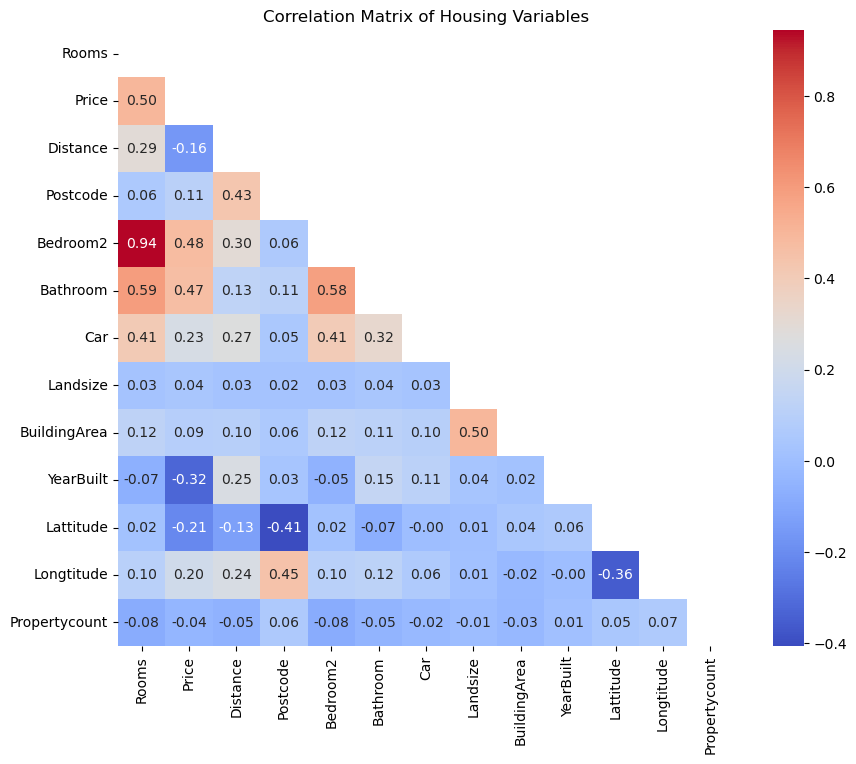

In [6]:
corr = df.corr(numeric_only=True)

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))

# Pass the mask into the heatmap function
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", square=True)

plt.title("Correlation Matrix of Housing Variables")

In [7]:
# remove columns that we do not need
df = df.drop(
    columns=[
        "BuildingArea",
        "SellerG",
        "Date",
        "Postcode",
        "Address",
        "Propertycount",
        "Method",
        "YearBuilt",
        "Suburb",
        "CouncilArea",
        "Bedroom2"],
    errors="ignore",
)

# creates new features for analysing
df = df.assign(
    Price_per_Landsize = lambda x: x['Price'] / x['Landsize'],
    Distance_Category = pd.cut(
        df['Distance'],
        bins=[0, 10, 20, 30, float('inf')],
        labels=['Near', 'Middle', 'Far', 'Outer']
    )
)

Text(0.5, 1.0, 'Correlation Matrix of Housing Variables')

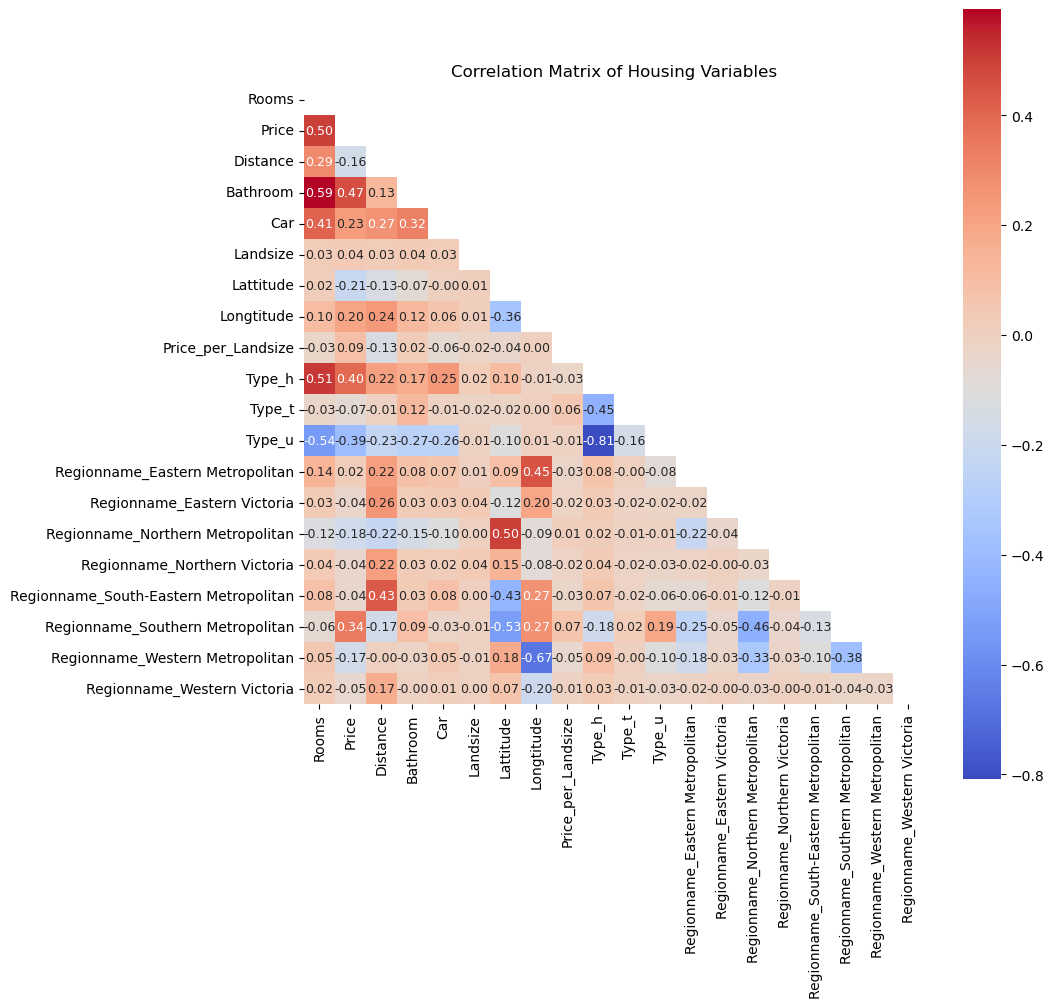

In [8]:
# Convert text columns into numeric binary columns (0 or 1)
df_encoded = pd.get_dummies(df, columns=["Type", "Regionname"], drop_first = False, dtype = int)

# Now calculate correlation on the newly encoded dataset
corr = df_encoded.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 10))

# Pass the mask into the heatmap function
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", square=True, annot_kws={"size": 9})

plt.title("Correlation Matrix of Housing Variables")

In [9]:
# Clean Landsize
Q1_land = df["Landsize"].quantile(0.25)
Q3_land = df["Landsize"].quantile(0.75)
IQR_land = Q3_land - Q1_land
lower_land = Q1_land - 1.5 * IQR_land
upper_land = Q3_land + 1.5 * IQR_land
df = df[(df["Landsize"] >= lower_land) & (df["Landsize"] <= upper_land)]

# Clean Price
Q1_price = df["Price"].quantile(0.25)
Q3_price = df["Price"].quantile(0.75)
IQR_price = Q3_price - Q1_price
lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price
df = df[(df["Price"] >= lower_price) & (df["Price"] <= upper_price)]

# Clean Price per landsize
Q1_Price_per_Landsize = df["Price_per_Landsize"].quantile(0.25)
Q3_Price_per_Landsize = df["Price_per_Landsize"].quantile(0.75)
IQR_Price_per_Landsize = Q3_Price_per_Landsize - Q1_Price_per_Landsize
lower_Price_per_Landsize = Q1_Price_per_Landsize - 1.5 * IQR_Price_per_Landsize
upper_Price_per_Landsize = Q3_Price_per_Landsize + 1.5 * IQR_Price_per_Landsize
df = df[(df["Price_per_Landsize"] >= lower_Price_per_Landsize) & (df["Price_per_Landsize"] <= upper_Price_per_Landsize)]


print("Total rows remaining:", len(df))

Total rows remaining: 10579


In [42]:
# missing values per column
missing_counts = df.isnull().sum()

# precentage of missing values
missing_percentages = (df.isnull().sum() / len(df)) * 100

# Table of missing count and percentage
missing_summary = pd.DataFrame(
    {'Missing Count': missing_counts,
    'Percentage (%)': missing_percentages})

# shows the varibles that has missing values in decending order
final_report = missing_summary[missing_summary['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print(final_report)

                   Missing Count  Percentage (%)
Distance_Category              1        0.009453


In [43]:
# remove the 1 missing value for Distance Category
df = df.dropna(subset=["Distance_Category"])
missing_count = df["Distance_Category"].isna().sum()

print(f"Missing values in Distance_category: {missing_count}")

Missing values in Distance_category: 0


In [44]:
print("Remaining inf values:", np.isinf(df["Price_per_Landsize"]).sum())
print("Total rows remaining:", len(df))

Remaining inf values: 0
Total rows remaining: 10578


In [22]:
# 1. Replace all inf and -inf values with NaN in the Price_per_landsize column
df["Price_per_Landsize"] = df["Price_per_Landsize"].replace(
    [np.inf, -np.inf], np.nan
)

# 2. Drop the rows where Price_per_landsize is now NaN
df = df.dropna(subset=["Price_per_Landsize"])

# Verify that all inf values are gone
print("Remaining inf values:", np.isinf(df["Price_per_Landsize"]).sum())
print("Total rows remaining:", len(df))
print(df.shape)

Remaining inf values: 0
Total rows remaining: 10579
(10579, 12)


In [123]:
df.head()

,Rooms,Type,Price,Distance,Bedroom2,Bathroom,Car,Landsize,Lattitude,Longtitude,Regionname,Price_per_Landsize,Distance_Category
0,2,h,1480000.0,2.5,2.0,1.0,1.0,202.0,-37.7996,144.9984,Northern Metropolitan,7326.732673,Near
1,2,h,1035000.0,2.5,2.0,1.0,0.0,156.0,-37.8079,144.9934,Northern Metropolitan,6634.615385,Near
2,3,h,1465000.0,2.5,3.0,2.0,0.0,134.0,-37.8093,144.9944,Northern Metropolitan,10932.835821,Near
3,3,h,850000.0,2.5,3.0,2.0,1.0,94.0,-37.7969,144.9969,Northern Metropolitan,9042.553191,Near
5,2,h,941000.0,2.5,2.0,1.0,0.0,181.0,-37.8041,144.9953,Northern Metropolitan,5198.895028,Near


In [46]:
df.to_csv('cleaned_melb_dataset.csv', index = False)

Text(0.5, 1.0, 'Correlation Matrix of Housing Variables')

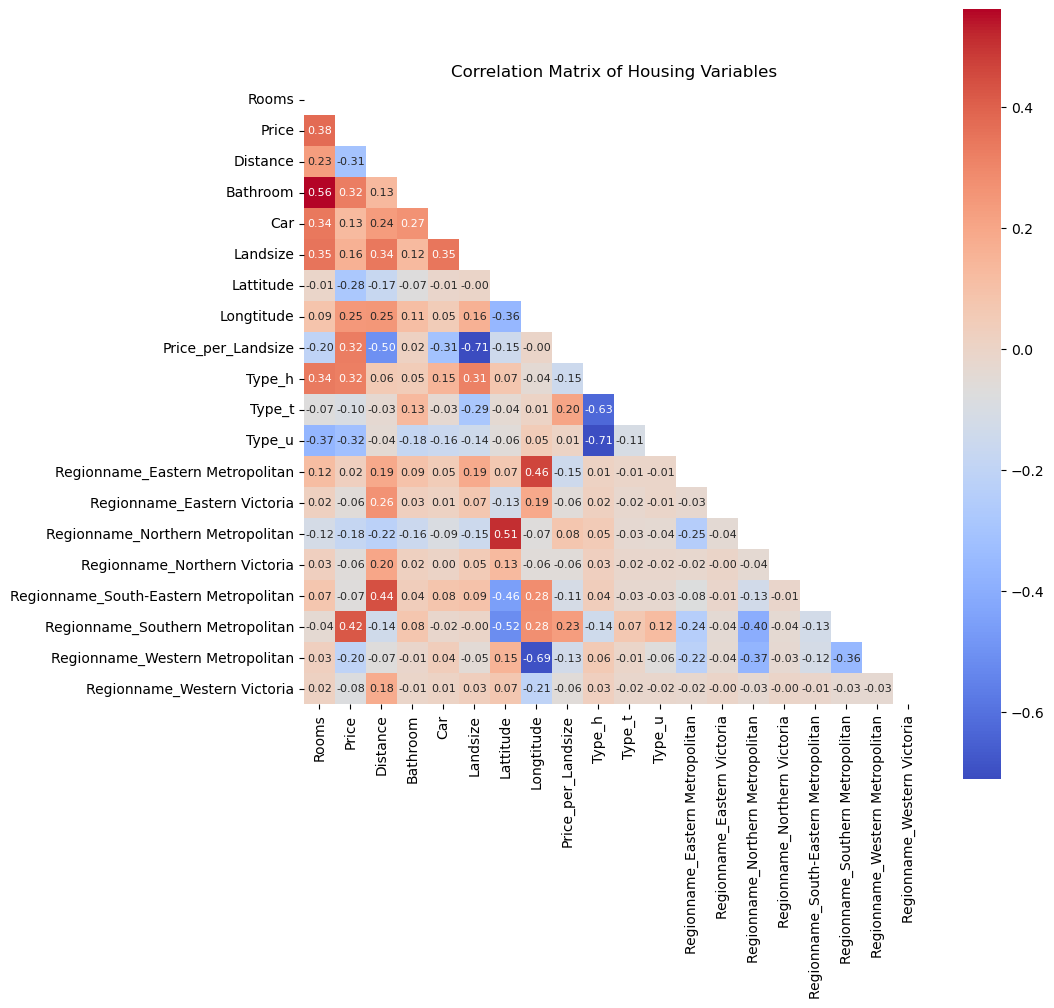

In [11]:
# Convert text columns into numeric binary columns (0 or 1)
df_encoded = pd.get_dummies(df, columns=["Type", "Regionname"])

# Now calculate correlation on the newly encoded dataset
corr = df_encoded.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 10))

# Pass the mask into the heatmap function
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", square=True, annot_kws={"size": 8})

plt.title("Correlation Matrix of Housing Variables")

In [19]:
# Get the absolute correlation values for Price
price_corr = corr["Price"].abs()

cols_above_04 = price_corr[price_corr > 0.4].index.tolist()
cols_above_03 = price_corr[price_corr > 0.3].index.tolist()

dataset_strong = df_encoded[cols_above_04]
dataset_weak = df_encoded[cols_above_03]

# 4. Save them as CSV files
dataset_strong.to_csv("dataset_above_0_4.csv", index=False)
dataset_weak.to_csv("dataset_above_0_3.csv", index=False)

In [20]:
print("Saved dataset_above_0_4.csv with columns:", cols_above_04)
print("Saved dataset_above_0_3.csv with columns:", cols_above_03)

Saved dataset_above_0_4.csv with columns: ['Price', 'Regionname_Southern Metropolitan']
Saved dataset_above_0_3.csv with columns: ['Rooms', 'Price', 'Distance', 'Bathroom', 'Price_per_Landsize', 'Type_h', 'Type_u', 'Regionname_Southern Metropolitan']
